# x86 CPU Governor — Configuration-Only DDQN

The configuration PCHIP teacher and 64×64 MLP student use **500 target-block/configuration medians**. The DDQN learns only the **50 sampling-rate/threshold configurations** from the configuration student's score surface. Independent frequency models are evaluated separately.

$$EDP_{service}=P_{measured}	imes ServiceTime^2$$

### Executed results

Ten complete held-out target blocks and three DDQN training seeds produce 30 state/seed evaluations.

| Component | Held-out result |
|---|---:|
| PCHIP Teacher | 3.91% mean oracle regret |
| MLP Configuration Student | 3.91% mean oracle regret |
| Configuration-only DDQN | 1.81% mean oracle regret |
| Linux Ondemand | 23.65% mean oracle regret |
| Independent frequency teacher | 12.50 MHz MAE |
| Independent frequency student | 10.20 MHz MAE |

The DDQN's mean per-state EDP reduction versus Ondemand is **17.03%**; it beats Ondemand in 100.0% of state/seed evaluations. The standard deviation of seed mean regret is 0.173 percentage points. Its configuration controller has 4,946 parameters and median inference latency 0.0204 ms in this environment.

All 11 code cells executed sequentially in a Python process; this environment could not launch a Jupyter TCP kernel.


**Scope.** Offline evaluation with `gamma=0`; EDP is looked up on the measured 500-cell surface. Measured utilization is observed after execution. These results do not establish sequential online control performance.


## 1. Context, assumptions, and configuration

**Configuration data.** Ten target-utilization blocks × 50 configurations. Each cell contains the median of run-level service-time EDP. A block's state `rho` is the median measured utilization under default Ondemand, divided by 100 and clipped to the numerical range. Configuration training uses this continuous block state.

**Independent frequency data.** Repetitions sharing target block, truncated integer measured utilization, sampling rate, and threshold are combined by the median. The RBF-SVR teacher and 32×32 MLP student use these robust cells. Frequency outputs are independent of the DDQN's state, action, reward, and training.

**Objective and units.** Run-level EDP equals measured core power in watts times measured mean service time in milliseconds squared, giving W·ms². EDP is calculated before aggregation.

**Validation.** Each fold excludes the entire evaluated target block before fitting either supervised stack. The DDQN trains on the held-out fold's configuration student only. Seeds 7, 42, and 123 randomize DDQN initialization, sampled training states, and epsilon-greedy exploration; supervised students retain seed 42. Reported regret is `EDP / oracle_EDP − 1`; reductions versus Ondemand average per-state EDP ratios with equal state/seed weight.

**Execution.** Requires Python 3 with NumPy, pandas, SciPy, scikit-learn, Matplotlib, and joblib. Run cells in order. The source CSV is loaded from the local path or its recorded URL; its SHA-256 is checked. Outputs are written to the configured results directory.


In [1]:
from __future__ import annotations

import re, time, warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})


@dataclass
class CFG:
    remote_url: str = "https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv"
    local_csv: str = "data/x86_mm1_clean.csv"
    seed: int = 42
    rl_seeds: Tuple[int, ...] = (7, 42, 123)
    sampling_rates: Tuple[int, ...] = tuple(range(10_000, 100_001, 10_000))
    thresholds: Tuple[int, ...] = (75, 80, 85, 90, 95)
    ondemand_sr: int = 10_000
    ondemand_thr: int = 95
    rho_eps: float = 1e-3
    fmin_khz: float = 800_000.0
    fmax_khz: float = 2_100_000.0

    config_student_hidden: Tuple[int, ...] = (64, 64)
    config_distill_points: int = 256
    config_student_epochs: int = 1_400
    config_student_lr: float = 2e-3

    freq_expert_C: float = 100.0
    freq_expert_gamma: float = 0.1
    freq_expert_epsilon: float = 5e-3
    freq_student_hidden: Tuple[int, ...] = (32, 32)
    freq_distill_points: int = 64
    freq_student_epochs: int = 900
    freq_student_lr: float = 5e-3

    gamma: float = 0.0
    rl_grid_points: int = 96
    rl_steps: int = 2_000
    rl_batch: int = 128
    rl_lr: float = 3e-3
    rl_hidden: Tuple[int, ...] = (48, 48)
    rl_target_tau: float = 0.05
    rl_eps_start: float = 1.0
    rl_eps_end: float = 0.05
    results_dir: str = "results_x86_service_time_edp_config_only"


CFG_ = CFG()
RESULTS = Path(CFG_.results_dir)
RESULTS.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG_.seed)
print("Configuration-only DDQN settings loaded.")


Configuration-only DDQN settings loaded.


## 2. Load data and build the model tables

- `TABLE`: 500 target/configuration medians for configuration training and service-time EDP evaluation.
- `MODEL_CELLS`: robust medians grouped by target block, truncated measured utilization, and configuration for the independent frequency models.

All observed utilization values remain in the source data.


In [2]:
CANONICAL = {
    "util_target_pct": ["cpuutilization", "targetedutilization", "targetutilization"],
    "sampling_rate_us": ["samplingrate"],
    "threshold_pct": ["threshold"],
    "service_time_ms": ["measuredmeanservicetime"],
    "power_w": ["measuredcorepower"],
    "freq_khz": ["measuredmeancorefrequency"],
    "measured_util_pct": ["measuredutilization"],
}


def norm_name(name):
    s = re.sub(r"\[.*?\]|\(.*?\)", " ", str(name))
    return re.sub(r"[^0-9a-zA-Z]+", "", s.replace("µ", "u")).lower()


def resolve_columns(df):
    lookup = {norm_name(c): c for c in df.columns}
    out = {}
    for key, candidates in CANONICAL.items():
        for candidate in candidates:
            if candidate in lookup:
                out[key] = lookup[candidate]
                break
    missing = sorted(set(CANONICAL) - set(out))
    if missing:
        raise KeyError(f"Missing columns: {missing}; available={list(df.columns)}")
    return out


from io import BytesIO
from urllib.request import urlopen
import hashlib

SOURCE_SHA256 = "1c2e5bd4d5839d7be4135775fd5474eaf7a99731dc055db4baccfd65d15c45fe"
local_data = Path(CFG_.local_csv)
if local_data.exists():
    data_bytes = local_data.read_bytes()
    DATA_SOURCE = str(local_data)
else:
    with urlopen(CFG_.remote_url, timeout=30) as response:
        data_bytes = response.read()
    DATA_SOURCE = CFG_.remote_url
DATA_SHA256 = hashlib.sha256(data_bytes).hexdigest()
if DATA_SHA256 != SOURCE_SHA256:
    raise ValueError("Source CSV differs from the validated dataset; use the recorded dataset version.")
raw = pd.read_csv(BytesIO(data_bytes))

cols = resolve_columns(raw)
runs = pd.DataFrame({key: pd.to_numeric(raw[col], errors="coerce") for key, col in cols.items()})
runs = runs.dropna().copy()
runs["sampling_rate_us"] = runs["sampling_rate_us"].astype(int)
runs["threshold_pct"] = runs["threshold_pct"].astype(int)
runs["util_target_pct"] = runs["util_target_pct"].round(6)
runs["edp"] = runs["service_time_ms"] ** 2 * runs["power_w"]
runs["log_edp"] = np.log10(runs["edp"])

ACTION_GRID = pd.DataFrame(
    [(sr, thr) for sr in CFG_.sampling_rates for thr in CFG_.thresholds],
    columns=["sampling_rate_us", "threshold_pct"],
)
ACTION_GRID.insert(0, "config_id", np.arange(len(ACTION_GRID)))
ACTION_GRID["sr_norm"] = (ACTION_GRID.sampling_rate_us - min(CFG_.sampling_rates)) / (max(CFG_.sampling_rates) - min(CFG_.sampling_rates))
ACTION_GRID["thr_norm"] = (ACTION_GRID.threshold_pct - min(CFG_.thresholds)) / (max(CFG_.thresholds) - min(CFG_.thresholds))
N_ACTIONS = len(ACTION_GRID)
SR_ARR = ACTION_GRID.sampling_rate_us.to_numpy()
THR_ARR = ACTION_GRID.threshold_pct.to_numpy()
SRN_ARR = ACTION_GRID.sr_norm.to_numpy()
THRN_ARR = ACTION_GRID.thr_norm.to_numpy()
ONDEMAND_ID = int(ACTION_GRID.query("sampling_rate_us == @CFG_.ondemand_sr and threshold_pct == @CFG_.ondemand_thr").config_id.iloc[0])
assert N_ACTIONS == 50

# Build workload-block identifiers and integer states for frequency modeling.
runs = runs.merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="inner")
runs["state_id"] = "x86@" + runs.util_target_pct.map(lambda v: f"{v:g}")
runs["util_state_int"] = np.floor(runs.measured_util_pct).astype(int)

# Robust model table (1,959 cells): used by the frequency stack. The target block
# stays in the grouping keys so an entire workload block can be excluded without leakage.
model_keys = ["state_id", "util_target_pct", "util_state_int",
              "sampling_rate_us", "threshold_pct", "config_id", "sr_norm", "thr_norm"]
MODEL_CELLS = (runs.groupby(model_keys, as_index=False)
               .agg(edp=("edp", "median"), freq_khz=("freq_khz", "median"),
                    n_reps=("edp", "size")))
MODEL_CELLS["log_edp"] = np.log10(MODEL_CELLS.edp)
MODEL_CELLS["rho"] = np.clip(MODEL_CELLS.util_state_int / 100.0, CFG_.rho_eps, 1-CFG_.rho_eps)
MODEL_CELLS["log_1m_rho"] = np.log10(np.clip(1-MODEL_CELLS.rho, CFG_.rho_eps, None))

# The 500 target/configuration medians: training table for the configuration stack
# and the policy-evaluation surface.
keys = ["util_target_pct", "sampling_rate_us", "threshold_pct"]
TABLE = (runs.groupby(keys)
         .agg(edp=("edp", "median"), freq_khz=("freq_khz", "median"), measured_util_pct=("measured_util_pct", "median"), n_reps=("edp", "size"))
         .reset_index().merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
TABLE["log_edp"] = np.log10(TABLE.edp)
TABLE["state_id"] = "x86@" + TABLE.util_target_pct.map(lambda v: f"{v:g}")

state_rows = []
for util, g in TABLE.groupby("util_target_pct"):
    if set(g.config_id.astype(int)) != set(range(N_ACTIONS)):
        continue
    ond = g[g.config_id == ONDEMAND_ID].iloc[0]
    oracle = g.loc[g.edp.idxmin()]
    rho = float(np.clip(ond.measured_util_pct / 100, CFG_.rho_eps, 1-CFG_.rho_eps))
    state_rows.append(dict(state_id=f"x86@{util:g}", util_target_pct=float(util), rho=rho,
                           log_1m_rho=float(np.log10(max(1-rho, CFG_.rho_eps))),
                           oracle_config_id=int(oracle.config_id), edp_oracle=float(oracle.edp),
                           edp_ondemand=float(ond.edp)))
STATES = pd.DataFrame(state_rows).sort_values("util_target_pct").reset_index(drop=True)
STATE_ROW = STATES.set_index("state_id")
STATE_IDS = STATES.state_id.tolist()
assert len(STATE_IDS) == 10

TABLE = TABLE[TABLE.state_id.isin(STATE_IDS)].merge(STATES[["util_target_pct", "rho", "log_1m_rho"]], on="util_target_pct", how="left")
MODEL_CELLS = MODEL_CELLS[MODEL_CELLS.state_id.isin(STATE_IDS)].copy()
EDP_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="edp").reindex(index=STATE_IDS, columns=range(N_ACTIONS))

print(f"Source: {DATA_SOURCE}")
print(f"Robust cells used by the frequency stack={len(MODEL_CELLS):,}")
print(f"Target/configuration medians used by the configuration stack={len(TABLE):,}")
print(f"Evaluation cells={len(TABLE)}; complete states={len(STATES)}; actions/state={N_ACTIONS}")
print(STATES.assign(ondemand_regret=STATES.edp_ondemand/STATES.edp_oracle-1)[["state_id","rho","oracle_config_id","ondemand_regret"]].to_string(index=False))


Source: data/x86_mm1_clean.csv
Robust cells used by the frequency stack=1,959
Target/configuration medians used by the configuration stack=500
Evaluation cells=500; complete states=10; actions/state=50
state_id    rho  oracle_config_id  ondemand_regret
  x86@10 0.1047                 0           0.3984
  x86@20 0.2060                 0           0.2702
  x86@30 0.3122                 0           0.2917
  x86@40 0.4162                 0           0.1512
  x86@50 0.5160                43           0.1808
  x86@60 0.6269                43           0.1180
  x86@70 0.7159                35           0.2317
  x86@80 0.8278                27           0.1741
  x86@90 0.9231                45           0.0663
 x86@100 0.9755                25           0.4831


## 3. Shared deterministic MLP implementation


In [3]:
class MLP:
    def __init__(self, sizes: Sequence[int], out_act="linear", seed=0, lr=3e-3):
        rng = np.random.default_rng(seed)
        self.sizes, self.out_act, self.lr = list(sizes), out_act, lr
        self.W = [rng.normal(0, np.sqrt(1/a), (a,b)) for a,b in zip(self.sizes[:-1], self.sizes[1:])]
        self.b = [np.zeros(b) for b in self.sizes[1:]]
        self._reset_adam()

    def _reset_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]; self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]; self.vb=[np.zeros_like(b) for b in self.b]; self.t=0

    def forward(self, X, cache=False):
        A=np.asarray(X,dtype=float); acts=[A]
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            Z=A@W+b
            if i < len(self.W)-1: A=np.tanh(Z)
            elif self.out_act=="sigmoid": A=1/(1+np.exp(-np.clip(Z,-30,30)))
            elif self.out_act=="tanh": A=np.tanh(Z)
            else: A=Z
            acts.append(A)
        if cache: self._acts=acts
        return A

    __call__=forward

    def backward(self,dY):
        acts=self._acts; dW=[None]*len(self.W); db=[None]*len(self.b); Y=acts[-1]
        if self.out_act=="sigmoid": dZ=dY*Y*(1-Y)
        elif self.out_act=="tanh": dZ=dY*(1-Y**2)
        else: dZ=dY
        for i in range(len(self.W)-1,-1,-1):
            dW[i]=acts[i].T@dZ; db[i]=dZ.sum(0); dA=dZ@self.W[i].T
            dZ=dA*(1-acts[i]**2) if i>0 else dA
        return dW,db,dZ

    def adam_step(self,dW,db,lr=None,b1=.9,b2=.999,eps=1e-8):
        self.t+=1; lr=self.lr if lr is None else lr
        for i in range(len(self.W)):
            self.mW[i]=b1*self.mW[i]+(1-b1)*dW[i]; self.vW[i]=b2*self.vW[i]+(1-b2)*dW[i]**2
            self.mb[i]=b1*self.mb[i]+(1-b1)*db[i]; self.vb[i]=b2*self.vb[i]+(1-b2)*db[i]**2
            self.W[i]-=lr*(self.mW[i]/(1-b1**self.t))/(np.sqrt(self.vW[i]/(1-b2**self.t))+eps)
            self.b[i]-=lr*(self.mb[i]/(1-b1**self.t))/(np.sqrt(self.vb[i]/(1-b2**self.t))+eps)

    def fit_regression(self,X,Y,epochs,batch=256,seed=0):
        X=np.asarray(X,float); Y=np.asarray(Y,float).reshape(len(X),-1); rng=np.random.default_rng(seed)
        for _ in range(epochs):
            for start in range(0,len(X),batch):
                ix=rng.permutation(len(X))[start:start+batch]
                pred=self.forward(X[ix],cache=True)
                dW,db,_=self.backward(2*(pred-Y[ix])/(len(ix)*Y.shape[1]))
                self.adam_step(dW,db)
        return self

    def copy(self):
        o=MLP(self.sizes,self.out_act,0,self.lr); o.W=[w.copy() for w in self.W]; o.b=[b.copy() for b in self.b]; return o

    def soft_update_from(self,src,tau):
        for i in range(len(self.W)):
            self.W[i]=(1-tau)*self.W[i]+tau*src.W[i]; self.b[i]=(1-tau)*self.b[i]+tau*src.b[i]

    @property
    def n_params(self): return int(sum(w.size for w in self.W)+sum(b.size for b in self.b))

print("MLP implementation ready.")


MLP implementation ready.


## 4. Configuration PCHIP teacher and score-producing MLP student

The configuration teacher is fitted from the 500 target-state/configuration medians. Service-time EDP is expressed as a log residual from the default-Ondemand median in the same target block. Each configuration has one median per training target block (9 per held-out fold, 10 for deployment), placed at that block's state utilization `rho`, so PCHIP receives a unique x per point and no duplicate combination is needed.

In [4]:
class PCHIPConfigurationTeacher:
    def fit(self, model_cells):
        work = model_cells.copy()
        self.rho_min = float(work.rho.min())
        self.rho_max = float(work.rho.max())
        baseline = (work[work.config_id == ONDEMAND_ID]
                    .groupby("util_target_pct")["log_edp"].median())
        work["log_edp_residual"] = work.log_edp - work.util_target_pct.map(baseline)
        if work.log_edp_residual.isna().any():
            raise ValueError("Every training target block must contain default-Ondemand runs.")

        self.curves = {}
        self.points_per_config = {}
        for cid, g in work.groupby("config_id"):
            # PCHIP requires a unique x. This combines only exact duplicate
            # measured-utilization coordinates, not integer/target states.
            support = (g.groupby("rho", as_index=False)
                       .agg(log_edp_residual=("log_edp_residual", "median"),
                            raw_rows=("log_edp_residual", "size"))
                       .sort_values("rho"))
            x = support.rho.to_numpy(float)
            y = support.log_edp_residual.to_numpy(float)
            if len(x) < 2:
                raise ValueError(f"Configuration {cid} has insufficient unique utilization support.")
            self.curves[int(cid)] = PchipInterpolator(x, y, extrapolate=True)
            self.points_per_config[int(cid)] = len(x)
        return self

    def score(self, rho):
        r = np.clip(np.atleast_1d(np.asarray(rho, float)), CFG_.rho_eps, 1-CFG_.rho_eps)
        return np.column_stack([self.curves[c](r) for c in range(N_ACTIONS)])

    def predict_config(self, rho):
        return np.argmin(self.score(rho), axis=1)


def state_features(rho):
    r=np.atleast_1d(np.asarray(rho,float)); return np.column_stack([r,np.log10(np.clip(1-r,CFG_.rho_eps,None))])


class ConfigurationScoreMLPStudent:
    # Returns a reward-like score for every configuration; higher is better.
    def __init__(self,seed=42):
        self.net=MLP([2,*CFG_.config_student_hidden,N_ACTIONS],"linear",seed,CFG_.config_student_lr)
    def distill(self,teacher):
        rho=np.linspace(teacher.rho_min,teacher.rho_max,CFG_.config_distill_points); X=state_features(rho)
        self.xmu=X.mean(0,keepdims=True); self.xsd=X.std(0,keepdims=True)+1e-9
        q=-teacher.score(rho); q=(q-q.mean(1,keepdims=True))/(q.std(1,keepdims=True)+1e-9)
        self.net.fit_regression((X-self.xmu)/self.xsd,q,CFG_.config_student_epochs,batch=128,seed=CFG_.seed)
        self.rho_min,self.rho_max=teacher.rho_min,teacher.rho_max
        return self
    def score(self,rho):
        X=(state_features(rho)-self.xmu)/self.xsd; return self.net.forward(X)
    def predict_config(self,rho): return np.argmax(self.score(rho),axis=1)


def fit_config_stack(train_ids):
    # One median per configuration and training target block, at its continuous state rho.
    train=TABLE[TABLE.state_id.isin(train_ids)].copy()
    teacher=PCHIPConfigurationTeacher().fit(train)
    student=ConfigurationScoreMLPStudent(CFG_.seed).distill(teacher)
    return teacher,student

print(f"Configuration teacher and MLP student defined on the {len(TABLE)} target-state/configuration medians.")


Configuration teacher and MLP student defined on the 500 target-state/configuration medians.


## 5. Independent frequency teacher and MLP student

The RBF-SVR teacher and 32×32 MLP student use robust cells and integer measured-utilization inputs. Their held-out predictions are reported separately from configuration policy performance.


In [5]:
FREQ_FEATURES=["rho","log_1m_rho","sr_norm","thr_norm"]

def freq_features(rho,srn,thrn):
    rho=np.atleast_1d(np.asarray(rho,float)); srn=np.atleast_1d(np.asarray(srn,float)); thrn=np.atleast_1d(np.asarray(thrn,float))
    rho,srn,thrn=np.broadcast_arrays(rho,srn,thrn)
    return np.column_stack([rho.ravel(),np.log10(np.clip(1-rho.ravel(),CFG_.rho_eps,None)),srn.ravel(),thrn.ravel()])


class FrequencyTeacher:
    def __init__(self):
        self.model=Pipeline([("scale",StandardScaler()),("svr",SVR(kernel="rbf",C=CFG_.freq_expert_C,gamma=CFG_.freq_expert_gamma,
            epsilon=CFG_.freq_expert_epsilon,tol=1e-3,max_iter=-1,cache_size=500))])
    def fit(self,table):
        X=table[FREQ_FEATURES].to_numpy(); y=(table.freq_khz-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)
        self.model.fit(X,y); self.rho_min=float(table.rho.min()); self.rho_max=float(table.rho.max()); return self
    def predict_norm(self,rho,srn,thrn): return np.clip(self.model.predict(freq_features(rho,srn,thrn)),0,1)
    def predict_grid_norm(self,rho): return self.predict_norm(np.full(N_ACTIONS,rho),SRN_ARR,THRN_ARR)


class FrequencyMLPStudent:
    def __init__(self,seed=42):
        self.net=MLP([4,*CFG_.freq_student_hidden,1],"sigmoid",seed,CFG_.freq_student_lr)
    def distill(self,teacher):
        rg=np.linspace(teacher.rho_min,teacher.rho_max,CFG_.freq_distill_points)
        X=freq_features(np.repeat(rg,N_ACTIONS),np.tile(SRN_ARR,len(rg)),np.tile(THRN_ARR,len(rg)))
        y=teacher.model.predict(X).clip(0,1).reshape(-1,1)
        self.net.fit_regression(X,y,CFG_.freq_student_epochs,batch=512,seed=CFG_.seed); return self
    def predict_norm(self,rho,srn,thrn): return self.net.forward(freq_features(rho,srn,thrn)).ravel().clip(0,1)
    def predict_grid_norm(self,rho): return self.predict_norm(np.full(N_ACTIONS,rho),SRN_ARR,THRN_ARR)
    def predict_grid_khz(self,rho): return CFG_.fmin_khz+self.predict_grid_norm(rho)*(CFG_.fmax_khz-CFG_.fmin_khz)


def fit_frequency_stack(train_ids):
    train=MODEL_CELLS[MODEL_CELLS.state_id.isin(train_ids)].copy()
    teacher=FrequencyTeacher().fit(train)
    student=FrequencyMLPStudent(CFG_.seed).distill(teacher)
    return teacher,student

print("Frequency teacher and MLP student defined on the 1,959 robust measured-utilization cells.")


Frequency teacher and MLP student defined on the 1,959 robust measured-utilization cells.


## 6. Complete-target-block held-out evaluation

Both supervised stacks are retrained after excluding the evaluated target block (its 50 medians from the configuration training table and every robust cell from the frequency training table). Configuration choices are scored on the unchanged 500-cell service-time EDP surface; frequency predictions are evaluated on the robust cells in the held-out block.

In [6]:
def policy_row(sid,policy,cid):
    row=STATE_ROW.loc[sid]; edp=float(EDP_MATRIX.loc[sid,cid])
    return dict(state_id=sid,policy=policy,config_id=int(cid),regret=edp/row.edp_oracle-1,
                delta_vs_ondemand=edp/row.edp_ondemand-1,exact_oracle=int(cid)==int(row.oracle_config_id))

CONFIG_ASSETS={}; FREQ_ASSETS={}; config_rows=[]; freq_rows=[]
for sid in STATE_IDS:
    train_ids=[s for s in STATE_IDS if s!=sid]
    ct,cs=fit_config_stack(train_ids); ft,fs=fit_frequency_stack(train_ids)
    CONFIG_ASSETS[sid]={"teacher":ct,"student":cs}; FREQ_ASSETS[sid]={"teacher":ft,"student":fs}
    rho=float(STATE_ROW.loc[sid,"rho"])
    config_rows += [policy_row(sid,"Oracle",int(STATE_ROW.loc[sid,"oracle_config_id"])),
                    policy_row(sid,"Linux Ondemand",ONDEMAND_ID),
                    policy_row(sid,"PCHIP Teacher",int(ct.predict_config(rho)[0])),
                    policy_row(sid,"MLP Configuration Student",int(cs.predict_config(rho)[0]))]

    # Evaluate frequency models on every robust model cell in the completely
    # held-out target block.
    held=MODEL_CELLS[MODEL_CELLS.state_id==sid].copy()
    tp=CFG_.fmin_khz+ft.predict_norm(held.rho,held.sr_norm,held.thr_norm)*(CFG_.fmax_khz-CFG_.fmin_khz)
    sp=CFG_.fmin_khz+fs.predict_norm(held.rho,held.sr_norm,held.thr_norm)*(CFG_.fmax_khz-CFG_.fmin_khz)
    for row,t_pred,s_pred in zip(held.itertuples(index=False),tp,sp):
        freq_rows.append(dict(state_id=sid,util_state_int=int(row.util_state_int),config_id=int(row.config_id),
                              measured_khz=float(row.freq_khz),teacher_khz=float(t_pred),student_khz=float(s_pred),
                              n_reps=int(row.n_reps)))

CONFIG_LOOCV=pd.DataFrame(config_rows); FREQ_LOOCV=pd.DataFrame(freq_rows)

def config_metrics(g):
    return dict(mean_regret=g.regret.mean(),median_regret=g.regret.median(),worst_regret=g.regret.max(),
                exact_oracle_rate=g.exact_oracle.mean(),within_5pct_oracle=(g.regret<=.05).mean(),
                mean_delta_vs_ondemand=g.delta_vs_ondemand.mean(),better_than_ondemand=(g.delta_vs_ondemand<0).mean())

CONFIG_SUMMARY=pd.DataFrame([{"policy":p,**config_metrics(g)} for p,g in CONFIG_LOOCV.groupby("policy")]).sort_values("mean_regret")

def freq_metrics(col):
    e=FREQ_LOOCV[col]-FREQ_LOOCV.measured_khz
    return dict(model=col.replace("_khz","").title(),MAE_MHz=np.abs(e).mean()/1e3,RMSE_MHz=np.sqrt(np.mean(e**2))/1e3,
                R2=r2_score(FREQ_LOOCV.measured_khz,FREQ_LOOCV[col]),
                bias_MHz=e.mean()/1e3,max_AE_MHz=np.abs(e).max()/1e3,
                legal_violation_pct=100*np.mean((FREQ_LOOCV[col]<CFG_.fmin_khz)|(FREQ_LOOCV[col]>CFG_.fmax_khz)))
FREQ_SUMMARY=pd.DataFrame([freq_metrics("teacher_khz"),freq_metrics("student_khz")])

print("CONFIGURATION RESULTS")
print(CONFIG_SUMMARY.to_string(index=False))
print("\nFREQUENCY RESULTS")
print(FREQ_SUMMARY.to_string(index=False))


CONFIGURATION RESULTS
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.1838                1.0000
MLP Configuration Student       0.0391         0.0048        0.1978             0.5000              0.8000                 -0.1553                1.0000
            PCHIP Teacher       0.0391         0.0048        0.1978             0.5000              0.8000                 -0.1553                1.0000
           Linux Ondemand       0.2365         0.2063        0.4831             0.0000              0.0000                  0.0000                0.0000

FREQUENCY RESULTS
  model  MAE_MHz  RMSE_MHz     R2  bias_MHz  max_AE_MHz  legal_violation_pct
Teacher  12.5009   24.5831 0.9558    5.1793    217.0759               0.0000
Student  10.1998   22.1920 0.9640    4.4

## 7. Configuration-student training surface

`make_student_surface` accepts only the configuration MLP student. Its 96-state reward table is a global affine normalization of the student's 50 configuration scores per state. The DDQN never receives teacher objects or frequency predictions.


In [7]:
@dataclass
class StudentSurface:
    state_id: str
    mu: np.ndarray
    sd: np.ndarray
    S: np.ndarray
    rho_grid: np.ndarray
    Q: np.ndarray

    def encode(self, rho):
        return (state_features(rho) - self.mu) / self.sd


def make_student_surface(config_student: ConfigurationScoreMLPStudent, state_id="fold"):
    lo = max(config_student.rho_min, CFG_.rho_eps)
    hi = min(config_student.rho_max, 1 - CFG_.rho_eps)
    rho = np.linspace(lo, hi, CFG_.rl_grid_points)
    raw = state_features(rho)
    mu = raw.mean(0, keepdims=True)
    sd = raw.std(0, keepdims=True) + 1e-9
    scores = config_student.score(rho)
    scores = (scores - scores.mean()) / (scores.std() + 1e-9)
    return StudentSurface(state_id, mu, sd, (raw - mu) / sd, rho, scores)


def build_surface(sid):
    return make_student_surface(CONFIG_ASSETS[sid]["student"], sid)


probe = build_surface(STATE_IDS[0])
assert probe.S.shape == (CFG_.rl_grid_points, 2)
assert probe.Q.shape == (CFG_.rl_grid_points, N_ACTIONS)
print(f"Configuration surface: states={probe.S.shape}, rewards={probe.Q.shape}")


Configuration surface: states=(96, 2), rewards=(96, 50)


## 8. Configuration-only DDQN

The network has two state inputs (`rho`, `log10(1−rho)`), two 48-unit tanh layers, and one **50-output configuration head**. The action is `(sampling_rate_us, threshold_pct)`.

Training samples the fixed configuration-student surface using epsilon-greedy exploration and Adam for 2,000 updates. Online action selection and target-network evaluation follow the Double-DQN update; the target network uses soft updates. With `gamma=0`, targets reduce to the immediate configuration score. This is offline one-step policy learning, without environment transitions or an online replay buffer.


In [8]:
class ConfigurationQNet:
    def __init__(self, in_dim, n_actions, seed):
        hidden = CFG_.rl_hidden[0]
        self.trunk = MLP([in_dim, hidden], "tanh", seed, CFG_.rl_lr)
        self.head = MLP([hidden, *CFG_.rl_hidden[1:], n_actions], "linear", seed + 1, CFG_.rl_lr)

    def q_config(self, states, cache=False):
        hidden = self.trunk.forward(states, cache=cache)
        return self.head.forward(hidden, cache=cache)

    def step_config(self, states, actions, targets):
        scores = self.q_config(states, cache=True)
        gradient = np.zeros_like(scores)
        rows = np.arange(len(states))
        gradient[rows, actions] = 2 * (scores[rows, actions] - targets) / len(states)
        dW, db, d_hidden = self.head.backward(gradient)
        dW_trunk, db_trunk, _ = self.trunk.backward(d_hidden)
        self.head.adam_step(dW, db)
        self.trunk.adam_step(dW_trunk, db_trunk)

    def copy(self):
        copied = ConfigurationQNet.__new__(ConfigurationQNet)
        copied.trunk = self.trunk.copy()
        copied.head = self.head.copy()
        return copied

    def soft_update_from(self, source, tau):
        self.trunk.soft_update_from(source.trunk, tau)
        self.head.soft_update_from(source.head, tau)

    @property
    def n_params(self):
        return self.trunk.n_params + self.head.n_params


def train_student_ddqn(surface, seed):
    if CFG_.gamma != 0:
        raise ValueError("This offline one-step training surface requires gamma=0.")
    rng = np.random.default_rng(seed)
    online = ConfigurationQNet(surface.S.shape[1], N_ACTIONS, seed)
    target = online.copy()
    for step in range(CFG_.rl_steps):
        epsilon = CFG_.rl_eps_end + (CFG_.rl_eps_start - CFG_.rl_eps_end) * (1 - step / CFG_.rl_steps)
        state_ids = rng.integers(0, len(surface.S), CFG_.rl_batch)
        states = surface.S[state_ids]
        greedy = np.argmax(online.q_config(states), axis=1)
        actions = np.where(
            rng.random(CFG_.rl_batch) < epsilon,
            rng.integers(0, N_ACTIONS, CFG_.rl_batch),
            greedy,
        )
        rewards = surface.Q[state_ids, actions]
        next_actions = np.argmax(online.q_config(states), axis=1)
        targets = rewards + CFG_.gamma * target.q_config(states)[np.arange(CFG_.rl_batch), next_actions]
        online.step_config(states, actions, targets)
        target.soft_update_from(online, CFG_.rl_target_tau)
    return online


def agent_action(net, surface, rho):
    cid = int(np.argmax(net.q_config(surface.encode(rho)), axis=1)[0])
    return dict(config_id=cid, sampling_rate_us=int(SR_ARR[cid]), threshold_pct=int(THR_ARR[cid]))


print("Configuration-only student-warmed DDQN defined.")


Configuration-only student-warmed DDQN defined.


## 9. Leave-one-state-out agent evaluation


In [9]:
rl_rows = []
fold_times = []
AGENT_LABEL = "Configuration-only DDQN"
for i, sid in enumerate(STATE_IDS, 1):
    start = time.perf_counter()
    surface = build_surface(sid)
    rho = float(STATE_ROW.loc[sid, "rho"])
    row = STATE_ROW.loc[sid]
    for seed in CFG_.rl_seeds:
        net = train_student_ddqn(surface, seed)
        action = agent_action(net, surface, rho)
        edp = float(EDP_MATRIX.loc[sid, action["config_id"]])
        rl_rows.append(dict(
            state_id=sid, seed=seed, **action, edp_service_w_ms2=edp,
            regret=edp / row.edp_oracle - 1,
            delta_vs_ondemand=edp / row.edp_ondemand - 1,
            exact_oracle=action["config_id"] == int(row.oracle_config_id),
        ))
    fold_times.append(time.perf_counter() - start)
    print(f"Fold {i:02d}/{len(STATE_IDS)} {sid}: {fold_times[-1]:.1f} s")

RL_LOOCV = pd.DataFrame(rl_rows)


def agent_metrics(frame):
    per_seed = [config_metrics(group) for _, group in frame.groupby("seed")]
    result = {key: float(np.mean([row[key] for row in per_seed])) for key in per_seed[0]}
    result["seed_std_mean_regret"] = float(np.std([row["mean_regret"] for row in per_seed], ddof=0))
    return result


AGENT_METRICS = agent_metrics(RL_LOOCV)
master = pd.concat([
    CONFIG_SUMMARY,
    pd.DataFrame([{"policy": AGENT_LABEL, **AGENT_METRICS}]),
], ignore_index=True).sort_values("mean_regret")
print("\nHELD-OUT CONFIGURATION POLICY RESULTS")
print(master.drop(columns="seed_std_mean_regret").to_string(index=False))
print(f"DDQN seed standard deviation of mean regret: {100 * AGENT_METRICS['seed_std_mean_regret']:.3f} pp")
print("\nDDQN RESULTS BY STATE AND SEED")
print(RL_LOOCV.to_string(index=False))


Fold 01/10 x86@10: 4.8 s
Fold 02/10 x86@20: 5.9 s
Fold 03/10 x86@30: 4.2 s
Fold 04/10 x86@40: 4.2 s
Fold 05/10 x86@50: 4.2 s
Fold 06/10 x86@60: 4.3 s
Fold 07/10 x86@70: 4.4 s
Fold 08/10 x86@80: 5.3 s
Fold 09/10 x86@90: 6.9 s
Fold 10/10 x86@100: 4.7 s

HELD-OUT CONFIGURATION POLICY RESULTS
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.1838                1.0000
  Configuration-only DDQN       0.0181         0.0000        0.1206             0.6000              0.9000                 -0.1703                1.0000
            PCHIP Teacher       0.0391         0.0048        0.1978             0.5000              0.8000                 -0.1553                1.0000
MLP Configuration Student       0.0391         0.0048        0.1978             0.5000            

## 10. Latency, checks, and visual evidence


INFERENCE LATENCY — 500 CALLS AFTER 30 WARM-UP CALLS (ms)
                    model  median_ms  p95_ms  p99_ms
MLP Configuration Student     0.0197  0.0220  0.0649
Independent Frequency MLP     0.0483  0.1087  0.3466
  Configuration-only DDQN     0.0204  0.0427  0.2065
[x] 50 configurations per evaluation state
[x] 500 configuration training/evaluation medians
[x] complete 30 state-seed evaluations
[x] configuration-only training path
[x] one 50-output agent head
[x] action contains only configuration
[x] gamma equals zero
[x] finite rewards and results


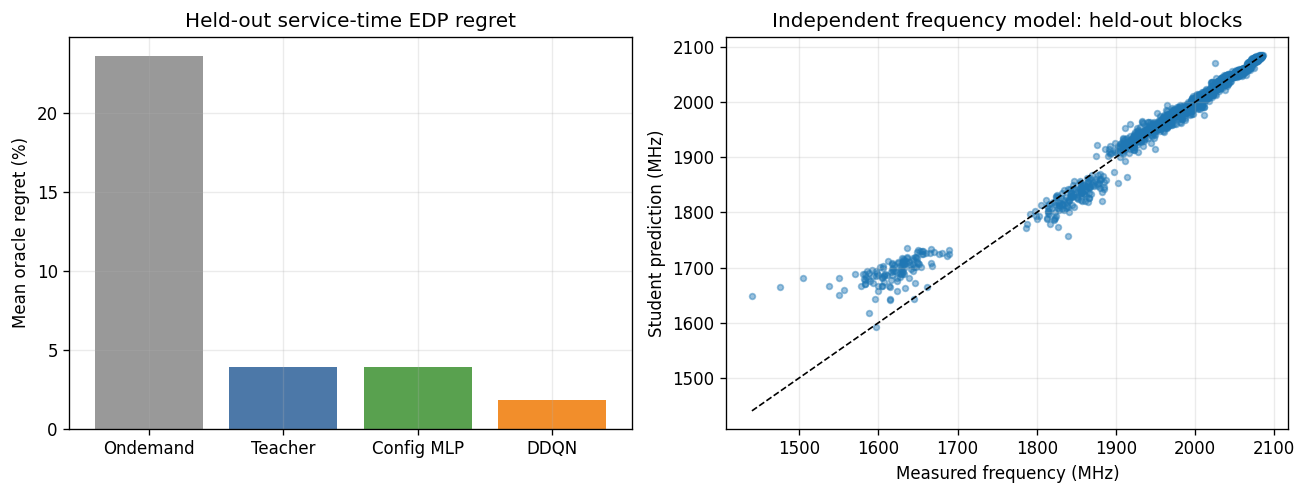

In [10]:
DEPLOY_CT, DEPLOY_CS = fit_config_stack(STATE_IDS)
DEPLOY_FT, DEPLOY_FS = fit_frequency_stack(STATE_IDS)
DEPLOY_SURFACE = make_student_surface(DEPLOY_CS, "deployment")
DEPLOY_NET = train_student_ddqn(DEPLOY_SURFACE, CFG_.seed)
DEMO_RHO = float(STATES.rho.median())


def bench(fn, n=500, warm=30):
    for _ in range(warm):
        fn()
    timings = []
    for _ in range(n):
        start = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - start) * 1e3)
    return np.median(timings), np.percentile(timings, 95), np.percentile(timings, 99)


LATENCY = pd.DataFrame([
    dict(model="MLP Configuration Student", **dict(zip(
        ["median_ms", "p95_ms", "p99_ms"], bench(lambda: DEPLOY_CS.predict_config(DEMO_RHO))))),
    dict(model="Independent Frequency MLP", **dict(zip(
        ["median_ms", "p95_ms", "p99_ms"], bench(lambda: DEPLOY_FS.predict_grid_khz(DEMO_RHO))))),
    dict(model=AGENT_LABEL, **dict(zip(
        ["median_ms", "p95_ms", "p99_ms"], bench(lambda: agent_action(DEPLOY_NET, DEPLOY_SURFACE, DEMO_RHO))))),
])
print("INFERENCE LATENCY — 500 CALLS AFTER 30 WARM-UP CALLS (ms)")
print(LATENCY.to_string(index=False))

import inspect
agent_code = "\n".join(inspect.getsource(obj) for obj in (
    make_student_surface, build_surface, ConfigurationQNet, train_student_ddqn, agent_action))
CHECKS = {
    "50 configurations per evaluation state": TABLE.groupby("state_id").config_id.nunique().eq(50).all(),
    "500 configuration training/evaluation medians": len(TABLE) == 500,
    "complete 30 state-seed evaluations": len(RL_LOOCV) == 30 and not RL_LOOCV.duplicated(["state_id", "seed"]).any(),
    "configuration-only training path": not any(token in agent_code.lower() for token in ("freq", "fhead", "centers", "bins")),
    "one 50-output agent head": DEPLOY_NET.head.sizes[-1] == 50 and not hasattr(DEPLOY_NET, "fhead"),
    "action contains only configuration": set(agent_action(DEPLOY_NET, DEPLOY_SURFACE, DEMO_RHO)) == {"config_id", "sampling_rate_us", "threshold_pct"},
    "gamma equals zero": CFG_.gamma == 0,
    "finite rewards and results": np.isfinite(DEPLOY_SURFACE.Q).all() and np.isfinite(RL_LOOCV[["regret", "delta_vs_ondemand"]]).all().all(),
}
for label, passed in CHECKS.items():
    print(f"[{'x' if passed else ' '}] {label}")
assert all(CHECKS.values())

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
plot_df = master.set_index("policy").loc[
    ["Linux Ondemand", "PCHIP Teacher", "MLP Configuration Student", AGENT_LABEL]]
ax[0].bar(["Ondemand", "Teacher", "Config MLP", "DDQN"], 100 * plot_df.mean_regret,
          color=["#999999", "#4c78a8", "#59a14f", "#f28e2b"])
ax[0].set_ylabel("Mean oracle regret (%)")
ax[0].set_title("Held-out service-time EDP regret")
ax[1].scatter(FREQ_LOOCV.measured_khz / 1e3, FREQ_LOOCV.student_khz / 1e3, s=12, alpha=.45)
lo = min(FREQ_LOOCV.measured_khz.min(), FREQ_LOOCV.student_khz.min()) / 1e3
hi = max(FREQ_LOOCV.measured_khz.max(), FREQ_LOOCV.student_khz.max()) / 1e3
ax[1].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[1].set_xlabel("Measured frequency (MHz)")
ax[1].set_ylabel("Student prediction (MHz)")
ax[1].set_title("Independent frequency model: held-out blocks")
fig.tight_layout()
fig.savefig(RESULTS / "configuration_policy_and_frequency_models.png", dpi=160)
plt.show()


## 11. Final performance and reproducibility record

The results below compare configuration policies on the same 500-cell service-time EDP surface. Frequency accuracy is reported for the independent supervised models only. Latency excludes data loading, governor writes, and workload execution.


In [11]:
idx = master.set_index("policy")
agent = idx.loc[AGENT_LABEL]
student = idx.loc["MLP Configuration Student"]
teacher = idx.loc["PCHIP Teacher"]
ondemand = idx.loc["Linux Ondemand"]
latency_ms = float(LATENCY.set_index("model").loc[AGENT_LABEL, "median_ms"])

print("FINAL RESULTS — CONFIGURATION-ONLY DDQN, SERVICE-TIME EDP")
print(f"Configuration teacher/student mean oracle regret: {100 * teacher.mean_regret:.2f}% / {100 * student.mean_regret:.2f}%.")
print(f"DDQN mean oracle regret: {100 * agent.mean_regret:.2f}% (seed standard deviation: {100 * agent.seed_std_mean_regret:.3f} pp).")
print(f"Ondemand mean oracle regret: {100 * ondemand.mean_regret:.2f}%.")
print(f"DDQN mean per-state EDP reduction versus Ondemand: {-100 * agent.mean_delta_vs_ondemand:.2f}%.")
print(f"DDQN beats Ondemand in {100 * agent.better_than_ondemand:.1f}% of held-out state/seed evaluations.")
print(f"DDQN controller: {DEPLOY_NET.n_params:,} parameters; median inference latency: {latency_ms:.4f} ms.")
print("Offline one-step configuration policy learning; gamma=0. EDP units: W·ms².")

frames = {
    "configuration_summary": CONFIG_SUMMARY, "configuration_folds": CONFIG_LOOCV,
    "frequency_summary": FREQ_SUMMARY, "frequency_folds": FREQ_LOOCV,
    "agent_per_state_seed": RL_LOOCV, "master_results": master,
    "latency": LATENCY, "evaluation_table": TABLE, "states": STATES,
}
for name, frame in frames.items():
    frame.to_csv(RESULTS / f"{name}.csv", index=False)

# Store portable weights rather than pickled notebook-defined network classes.
weights = {"state_mean": DEPLOY_SURFACE.mu, "state_std": DEPLOY_SURFACE.sd,
           "sampling_rates_us": SR_ARR, "thresholds_pct": THR_ARR}
for name, network in [("trunk", DEPLOY_NET.trunk), ("head", DEPLOY_NET.head)]:
    for layer, (weight, bias) in enumerate(zip(network.W, network.b)):
        weights[f"{name}_W{layer}"] = weight
        weights[f"{name}_b{layer}"] = bias
np.savez(RESULTS / "configuration_only_ddqn_weights.npz", **weights)

import json, platform
run_metadata = {
    "agent_type": "DDQN", "action": ["sampling_rate_us", "threshold_pct"],
    "state_features": ["rho", "log10(1-rho)"], "gamma": CFG_.gamma,
    "controller_parameters": DEPLOY_NET.n_params, "agent_metrics": AGENT_METRICS,
    "raw_rows": len(raw), "usable_runs": len(runs),
    "configuration_cells": len(TABLE), "independent_frequency_cells": len(MODEL_CELLS),
    "seeds": list(CFG_.rl_seeds), "checks": {key: bool(value) for key, value in CHECKS.items()},
    "data_source": DATA_SOURCE, "data_sha256": DATA_SHA256,
    "python_version": platform.python_version(),
}
(RESULTS / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2))
print(f"\nResult tables and configuration-only weights saved in {RESULTS}.")


FINAL RESULTS — CONFIGURATION-ONLY DDQN, SERVICE-TIME EDP
Configuration teacher/student mean oracle regret: 3.91% / 3.91%.
DDQN mean oracle regret: 1.81% (seed standard deviation: 0.173 pp).
Ondemand mean oracle regret: 23.65%.
DDQN mean per-state EDP reduction versus Ondemand: 17.03%.
DDQN beats Ondemand in 100.0% of held-out state/seed evaluations.
DDQN controller: 4,946 parameters; median inference latency: 0.0204 ms.
Offline one-step configuration policy learning; gamma=0. EDP units: W·ms².

Result tables and configuration-only weights saved in results_x86_service_time_edp_config_only.
